In [1]:
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)
print("features:", len(feature_cols))

train: (8644, 60) (8644,)
test:  (2162, 60) (2162,)
features: 60


In [2]:
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [3]:
param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

start_train = time.time()
grid.fit(X_train, y_train)
train_time = time.time() - start_train

print("Best params:", grid.best_params_)

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [4]:
best_model = grid.best_estimator_

start_pred = time.time()
y_pred = best_model.predict(X_test)
pred_time = time.time() - start_pred

In [5]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("F1:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("Training Time:", train_time)
print("Prediction Time:", pred_time)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.17668825161887142
F1: 0.10482070511471582
Precision: 0.13326888446517837
Recall: 0.17668825161887142
Training Time: 879.999922990799
Prediction Time: 0.845984935760498

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        86
           3       0.17      0.66      0.27       356
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00         4
           6       0.00      0.00      0.00        35
           7       0.00      0.00      0.00         5
           8       0.00      0.00      0.00       130
           9       0.15      0.34      0.21       289
          10       0.00      0.00      0.00        44
          11       0.00      0.00      0.00        88
          12       0.00      0.00      0.00        66
          13       0.00      0.00      

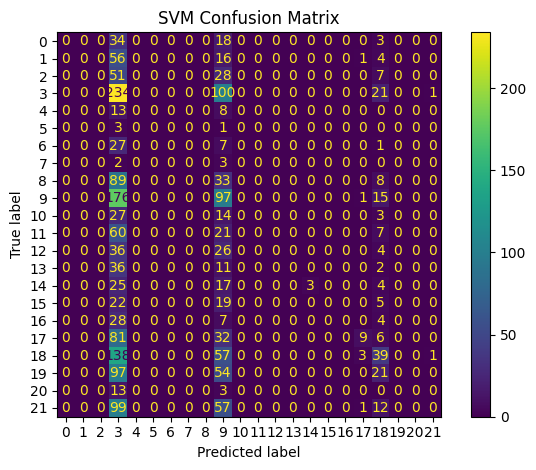

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()